## **Table of Content**

- [Introduction](#1)
- [Exploratory Data Analysis (EDA)](#2)
- [Text Preprocessing](#3)
- [Build Model](#4)
- [Conclusion](#5)

<a id='1'></a>




## Inroduction

In this part of the project, we worked on the task of analyzing the text and the content of our dataset related to the sentiment analysis of Twitter tweets, using the most important methods that helped us understand the data that seems to be unclear, into data that we are able to assimilate and understand and extract patterns and relationships from it, then two models of machine learning were built, namely Naive Bayes, Logistic Regression,  These two models helped us analyze emotions, and then we evaluated the models and extracted the results. 

## Main Objectives 

1. processing, and transforming textual 
data to obtain a structured representation of the data.

2. Using Method techniques , such as : Tokenization and Removing Stop Words and others... to extract 
knowledge from the data.

3. Good results and understanding of data 

4. Building more than one model to analyze emotions and explore patterns.





In [1]:
#load nussery libry

! pip install nltk
! pip install wordcloud


import re
import nltk
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings('ignore')

### **Understand The Data**
###### In this phase we will know the  nature of the dataset and selcted the important features

In [2]:
# Loading Dataset
df = pd.read_csv('Twitter.csv', encoding="ISO-8859-1", header=None, on_bad_lines='skip', engine='python')
df.columns = ["sentiment", "id", "date", "flag", "user", "text"]
df['sentiment'] = df['sentiment'].map({0:"Negative", 4:"Positive"})
df.head()



,sentiment,id,date,flag,user,text
0,Negative,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,Negative,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,Negative,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,Negative,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,Negative,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [3]:
# Selcting Important Features
df = df[['sentiment','text']]
df.head()

,sentiment,text
0,Negative,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,Negative,is upset that he can't update his Facebook by ...
2,Negative,@Kenichan I dived many times for the ball. Man...
3,Negative,my whole body feels itchy and like its on fire
4,Negative,"@nationwideclass no, it's not behaving at all...."


<a id='2'></a>


## **EDA**

In [4]:
# shape
df.shape

(1600000, 2)

In [5]:
# information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   sentiment  1600000 non-null  object
 1   text       1600000 non-null  object
dtypes: object(2)
memory usage: 24.4+ MB


In [6]:
# checking missing data
df.isnull().sum()

sentiment    0
text         0
dtype: int64

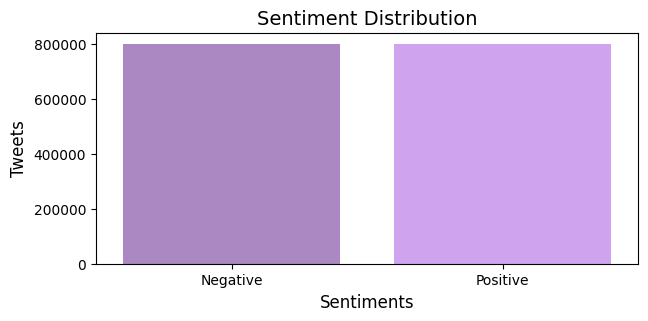

In [7]:
# Positive & Negative Data
plt.figure(figsize=(7,3))
colors = sns.dark_palette("#d397fa", n_colors=10, input='rgb')
sns.countplot(data=df, x='sentiment', palette=[colors[7], colors[9]])
plt.xlabel("Sentiments", size=12)
plt.ylabel('Tweets', size=12)
plt.title("Sentiment Distribution", size=14)
plt.show()

In [8]:
# Random Text Sample Analysis
random_index = [random.randint(0, df.shape[0]) for i in range(10)]
for i in df['text'].loc[random_index]:
    print(i)

@BstiNatosi shit. no sooner than i had replied to you about not having a lot of fails, twitter decided to go &quot;nyah-nyah, how about NOW?&quot; 
@cazp09  lol y? is it really gross??  i'm HUNGRY and theres nothin to have  
@ddlovato Bawled my eyes out! Really! Did the ugly cry! Lol 
argh!  I hate IE &amp; know it always freezes on me &amp; I know I should save as I go along but I don't &amp; now I lost a loooong post for Gather. 
I wrote him a letter telling him how I really feel. I can't believe this makes it officially over w/ no chance of getting back together. 
@CKova I'm still a novice at this whole iPhone thing, so no 
Good Day Twitters! 
@pinkytoy I started a month before u na sis. 
Don't forget to watch Dane Cook tonight on comedy channel-10pm. Will be hilarious! DVR if you go to bed too early 
so hungry I could barf, I'm waaaaaay late on lunch 


<a id='3'></a>



## **Text Preprocessing**


In [9]:
# All Patterns
mention_pattern = r'@\S+|#\S+'  # Pattern to match mentions (words starting with @ and #)
url_pattern = r"https?:(?:www\.)?\S+"  # Pattern to match URLs (starting with http or https)
non_alphanumeric_pattern = r"[^A-Za-z0-9\s]+"  # Pattern to match non-alphanumeric characters (including punctuation)

#### **Lowercasing** 

In [10]:
# Data Cleaning Function 
def data_cleaning(text):
    # Lowercasing 
    lower_text = str.lower(text)
    
    # Removing all unnecessary data 
    clean_text = re.sub(mention_pattern + '|' + url_pattern + '|' + non_alphanumeric_pattern, ' ', lower_text)
    
    return clean_text

In [11]:
# Performing Data Cleaning
df['text'] = df['text'].apply(data_cleaning)

df['cleaned_text'] = df['text'].apply(data_cleaning)


#### **Tokenization**

In [12]:
def simple_tokenize(text):

    return re.findall(r'\b\w+\b', text.lower())

df['cleaned_text'] = df['cleaned_text'].apply(simple_tokenize)
# Display the DataFrame after Tokenization
df

,sentiment,text,cleaned_text
0,Negative,awww that s a bummer you shoulda got ...,"[awww, that, s, a, bummer, you, shoulda, got, ..."
1,Negative,is upset that he can t update his facebook by ...,"[is, upset, that, he, can, t, update, his, fac..."
2,Negative,i dived many times for the ball managed to ...,"[i, dived, many, times, for, the, ball, manage..."
3,Negative,my whole body feels itchy and like its on fire,"[my, whole, body, feels, itchy, and, like, its..."
4,Negative,no it s not behaving at all i m mad why a...,"[no, it, s, not, behaving, at, all, i, m, mad,..."
...,...,...,...
1599995,Positive,just woke up having no school is the best fee...,"[just, woke, up, having, no, school, is, the, ..."
1599996,Positive,thewdb com very cool to hear old walt interv...,"[thewdb, com, very, cool, to, hear, old, walt,..."
1599997,Positive,are you ready for your mojo makeover ask me f...,"[are, you, ready, for, your, mojo, makeover, a..."
1599998,Positive,happy 38th birthday to my boo of alll time tu...,"[happy, 38th, birthday, to, my, boo, of, alll,..."


### **Stopword Removal**

In [13]:
# Stopword Removal
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
df['cleaned_text'] = df['cleaned_text'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
# Display the DataFrame after stopword removal
df

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,sentiment,text,cleaned_text
0,Negative,awww that s a bummer you shoulda got ...,"[awww, bummer, shoulda, got, david, carr, thir..."
1,Negative,is upset that he can t update his facebook by ...,"[upset, update, facebook, texting, might, cry,..."
2,Negative,i dived many times for the ball managed to ...,"[dived, many, times, ball, managed, save, 50, ..."
3,Negative,my whole body feels itchy and like its on fire,"[whole, body, feels, itchy, like, fire]"
4,Negative,no it s not behaving at all i m mad why a...,"[behaving, mad, see]"
...,...,...,...
1599995,Positive,just woke up having no school is the best fee...,"[woke, school, best, feeling, ever]"
1599996,Positive,thewdb com very cool to hear old walt interv...,"[thewdb, com, cool, hear, old, walt, interviews]"
1599997,Positive,are you ready for your mojo makeover ask me f...,"[ready, mojo, makeover, ask, details]"
1599998,Positive,happy 38th birthday to my boo of alll time tu...,"[happy, 38th, birthday, boo, alll, time, tupac..."


### **Lemmatization**

In [14]:
import nltk

# Downloading the WordNet dataset for lemmatization
nltk.download('wordnet')

# Downloading the omw-1.4 dataset to avoid potential issues
nltk.download('omw-1.4')

# Importing the WordNetLemmatizer to perform lemmatization
from nltk.stem import WordNetLemmatizer

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Applying lemmatization to the 'cleaned_text' column of the DataFrame
# Each word in the token list is lemmatized
df['cleaned_text'] = df['cleaned_text'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

# Display the DataFrame after lemmatization
df


[nltk_data] Downloading package wordnet to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/codespace/nltk_data...


,sentiment,text,cleaned_text
0,Negative,awww that s a bummer you shoulda got ...,"[awww, bummer, shoulda, got, david, carr, thir..."
1,Negative,is upset that he can t update his facebook by ...,"[upset, update, facebook, texting, might, cry,..."
2,Negative,i dived many times for the ball managed to ...,"[dived, many, time, ball, managed, save, 50, r..."
3,Negative,my whole body feels itchy and like its on fire,"[whole, body, feel, itchy, like, fire]"
4,Negative,no it s not behaving at all i m mad why a...,"[behaving, mad, see]"
...,...,...,...
1599995,Positive,just woke up having no school is the best fee...,"[woke, school, best, feeling, ever]"
1599996,Positive,thewdb com very cool to hear old walt interv...,"[thewdb, com, cool, hear, old, walt, interview]"
1599997,Positive,are you ready for your mojo makeover ask me f...,"[ready, mojo, makeover, ask, detail]"
1599998,Positive,happy 38th birthday to my boo of alll time tu...,"[happy, 38th, birthday, boo, alll, time, tupac..."


### **Stemming**

In [15]:
def preprocess(text, stem=False):
  text = re.sub(text_cleaning_re, ' ', str(text).lower()).strip()
  tokens = []
  for token in text.split():
    if token not in stop_words:
      if stem:
        tokens.append(stemmer.stem(token))
      else:
        tokens.append(token)
  return " ".join(tokens)

# Display the DataFrame after Stemmer
df

,sentiment,text,cleaned_text
0,Negative,awww that s a bummer you shoulda got ...,"[awww, bummer, shoulda, got, david, carr, thir..."
1,Negative,is upset that he can t update his facebook by ...,"[upset, update, facebook, texting, might, cry,..."
2,Negative,i dived many times for the ball managed to ...,"[dived, many, time, ball, managed, save, 50, r..."
3,Negative,my whole body feels itchy and like its on fire,"[whole, body, feel, itchy, like, fire]"
4,Negative,no it s not behaving at all i m mad why a...,"[behaving, mad, see]"
...,...,...,...
1599995,Positive,just woke up having no school is the best fee...,"[woke, school, best, feeling, ever]"
1599996,Positive,thewdb com very cool to hear old walt interv...,"[thewdb, com, cool, hear, old, walt, interview]"
1599997,Positive,are you ready for your mojo makeover ask me f...,"[ready, mojo, makeover, ask, detail]"
1599998,Positive,happy 38th birthday to my boo of alll time tu...,"[happy, 38th, birthday, boo, alll, time, tupac..."


### **Word Cloud**

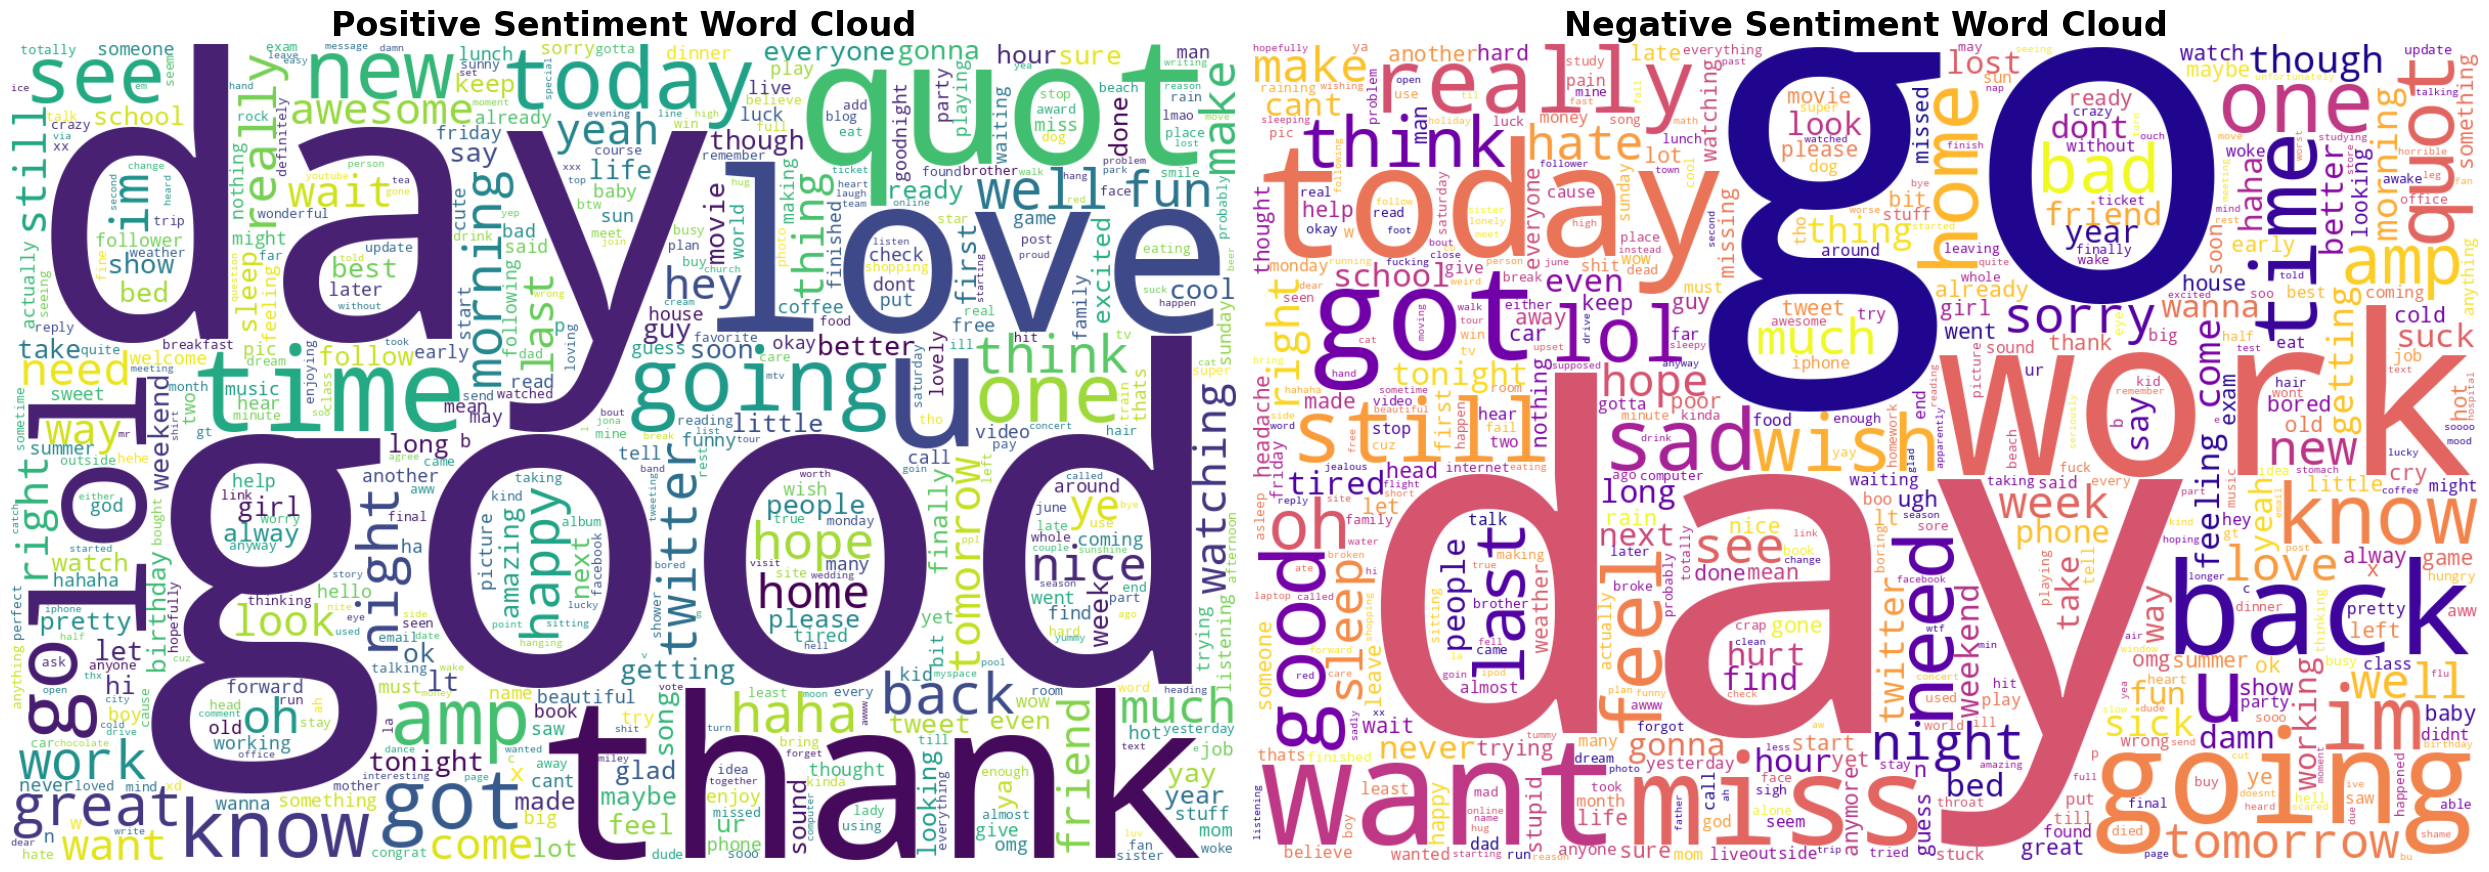

In [16]:
# Filter out positive and negative sentiment data
positive = df[df['sentiment'] == 'Positive']['cleaned_text'].apply(lambda x: " ".join(x))
negative = df[df['sentiment'] == 'Negative']['cleaned_text'].apply(lambda x: " ".join(x))

# Combine text data into single strings
positive_data = " ".join(positive)
negative_data = " ".join(negative)

# Create WordCloud objects
wc_positive = WordCloud(max_words=500, width=1200, height=800, background_color='white', colormap='viridis',
                        contour_color='black', contour_width=1, collocations=False, random_state=42).generate(positive_data)

wc_negative = WordCloud(max_words=500, width=1200, height=800, background_color='white', colormap='plasma',
                        contour_color='black', contour_width=1, collocations=False, random_state=42).generate(negative_data)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(25, 10))

# Plot positive sentiment word cloud
axes[0].imshow(wc_positive, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title("Positive Sentiment Word Cloud", fontsize=24, fontweight='bold')

# Plot negative sentiment word cloud
axes[1].imshow(wc_negative, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title("Negative Sentiment Word Cloud", fontsize=24, fontweight='bold')

plt.tight_layout()
plt.show()


<a id='4'></a>



### **Build Model Multinomial NB & Logistic Regression**

#### **Using TF-IDF**

In [22]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Assuming df is already defined and contains 'cleaned_text' and 'sentiment'

# Debug: Check the data type and sample entries
print("Data type of 'cleaned_text':", type(df['cleaned_text']))
print("Sample entries from 'cleaned_text':", df['cleaned_text'].head())

# Check if 'cleaned_text' contains lists or strings
if df['cleaned_text'].apply(lambda x: isinstance(x, list)).any():
    print("Detected lists in 'cleaned_text'. Flattening the lists.")
    # Flatten the lists into a single string (if they contain strings)
    df['cleaned_text'] = df['cleaned_text'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

# Step 1: Prepare the data
X = df['cleaned_text']
y = df['sentiment'].map({"Negative": 0, "Positive": 1})

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Step 3: Vectorize the text data using TfidfVectorizer
vectorizer = TfidfVectorizer(ngram_range=(1, 2))  # Using both unigrams and bigrams
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


Data type of 'cleaned_text': <class 'pandas.core.series.Series'>
Sample entries from 'cleaned_text': 0         awww bummer shoulda got david carr third day
1    upset update facebook texting might cry result...
2    dived many time ball managed save 50 rest go b...
3                      whole body feel itchy like fire
4                                     behaving mad see
Name: cleaned_text, dtype: object


In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 4: Initialize the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB()
}

# Dictionary to store the performance metrics of each model
model_performance = {}

# Step 5: Train and evaluate the models
for model_name, model in models.items():
    # Train the model using TF-IDF transformed data
    model.fit(X_train_tfidf, y_train)
    
    # Make predictions using TF-IDF transformed data
    y_train_pred = model.predict(X_train_tfidf)
    y_test_pred = model.predict(X_test_tfidf)

    # Calculate performance metrics
    training_accuracy = accuracy_score(y_train, y_train_pred)
    testing_accuracy = accuracy_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred, average='weighted')
    precision = precision_score(y_test, y_test_pred, average='weighted')
    f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    # Store the performance metrics in a dictionary
    model_performance[model_name] = {
        "Training Accuracy": training_accuracy,
        "Testing Accuracy": testing_accuracy,
        "Recall": recall,
        "Precision": precision,
        "F1 Score": f1
    }
    
    # Print the results
    print(f"Model: {model_name}")
    print(f"Training Accuracy: {training_accuracy:.4f}")
    print(f"Testing Accuracy: {testing_accuracy:.4f}")
    print("--" * 20)


Model: Logistic Regression
Training Accuracy: 0.8548
Testing Accuracy: 0.7922
----------------------------------------
Model: Naive Bayes
Training Accuracy: 0.8992
Testing Accuracy: 0.7775
----------------------------------------


In [24]:
# Step 6: Calculate and display the average accuracy for each model
for model_name, metrics in model_performance.items():
    avg_accuracy = (metrics["Training Accuracy"] + metrics["Testing Accuracy"]) / 2
    print(f"Model: {model_name}")
    print(f"Average Accuracy: {avg_accuracy:.4f}")
    print("--" * 20)


Model: Logistic Regression
Average Accuracy: 0.8235
----------------------------------------
Model: Naive Bayes
Average Accuracy: 0.8383
----------------------------------------


### **Evaluation The Model**

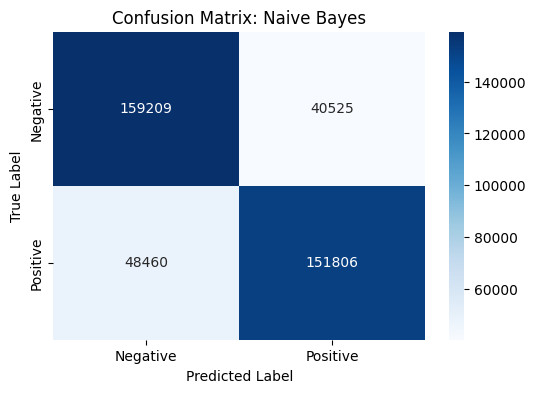

In [27]:
#  Create and plot the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title(f'Confusion Matrix: {model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [25]:
# Convert model performance dictionary to DataFrame
df_performance = pd.DataFrame(model_performance).T
df_performance.reset_index(inplace=True)
df_performance.rename(columns={'index': 'Model'}, inplace=True)
df_performance.style.background_gradient(cmap='Purples')

,Model,Training Accuracy,Testing Accuracy,Recall,Precision,F1 Score
0,Logistic Regression,0.854813,0.792153,0.792153,0.792221,0.792137
1,Naive Bayes,0.899153,0.777537,0.777537,0.777987,0.777456


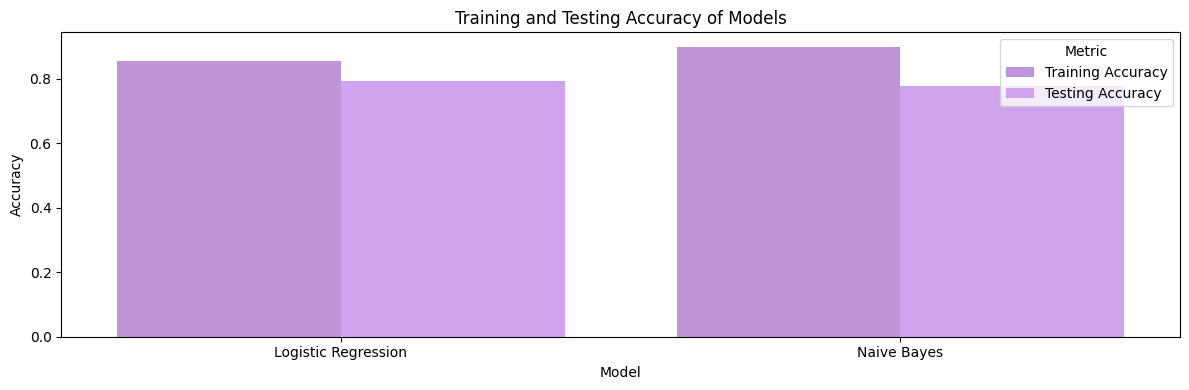

In [26]:
df_melted = df_performance.melt(id_vars='Model', value_vars=['Training Accuracy', 'Testing Accuracy'],
                                var_name='Metric', value_name='Score')

# Plot training and testing accuracy
plt.figure(figsize=(12, 4))
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette=[colors[8], colors[9]])
plt.title('Training and Testing Accuracy of Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


<a id='5'></a>


## **End**

Finally, work has been completed on this section of the project, and we have been keen to work according to clear and sound steps, the data that contains symbols that seem annoying and that would hinder the analysis was cleaned at the beginning of our work, then we analyzed the texts using four methods, namely Tokenization, Removing Stop Words, Lemmatization, Stemming, and then we moved to building two models, Naive Bayes and Logistic Regression using their algorithms and methods,  The final step was to evaluate the results and represent them through a matrix and a drawing.

Best regards. 